In [36]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.io import ascii
import seaborn as sns
from spectral_cube import SpectralCube
from scipy.optimize import curve_fit

FWHM_const = 2 * np.sqrt(2 * np.log(2))
nu11 = 23.6944955e9

size_convert = 1.5 # Conversion factor derived from comparing (crossmatching) ClumpFind outputs from RAMPS with RAMPS catalog
linewidth_convert = 2.5

In [37]:
Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_bl.fits') # Bring in spectral cube to obtain longitude, latitude, and V_LSR values from pixel values

hdr = Cube.header
x_channel_width = abs(hdr['CDELT1']) # Pixel size in degrees (channel width of x axis, longitude)
# y_channel_width = hdr['CDELT2']
v_channel_width = hdr['CDELT3'] # Channel width (Hz) (channel width of v axis, velocity)

def expFunc(x, a, b):
    return a * np.power(x, b)

In [38]:
hdul = fits.open("/home/scratch/hfwest/Pilot/Results_ClumpFind/Pilot_07_cat.FIT")
pilot_table = Table(hdul[1].data)
pilot_table['Linear Size (pc)'] = np.zeros(len(pilot_table))
pilot_table['sigma (km/s)'] = np.zeros(len(pilot_table))
pilot_table['Size1'] *= size_convert
pilot_table['Size2'] *= size_convert
for row in pilot_table:
    row['Linear Size (pc)'] = max(row['Size1'], row['Size2']) * x_channel_width * 7000 # Assumed distance to midpoint cloud: 7 kpc --> now in pc
    row['sigma (km/s)'] = row['Size3'] * v_channel_width * linewidth_convert * (3e8 / nu11) / 1000
pilot_table

PIDENT,Peak1,Peak2,Peak3,Cen1,Cen2,Cen3,Size1,Size2,Size3,Sum,Peak,Volume,Linear Size (pc),sigma (km/s)
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,163.5,44.5,193.5,163.53751281545334,44.52370131196119,193.88510487927687,3.267120421580416,2.659624674278428,4.047538935438311,360.5519726162275,1.6176305723032434,825.0,57.17460737765728,7.329888004936782
2,66.5,66.5,167.5,65.86973328980196,65.42761175145944,168.8171908930256,4.8510308304782015,5.169315735237696,3.057563401202309,1009.7945748137349,1.5137749714504212,2376.0,90.46302536665968,5.537092454523737
3,149.5,34.5,201.5,149.29992658980714,35.84834116759818,204.8743307254102,2.9750007595921524,4.65036755675098,4.706436590898205,438.61242585915375,1.4119234086414716,971.0,81.38143224314214,8.523118285923179
4,101.5,25.5,197.5,101.35880616408315,23.52025174607809,198.71828922406831,5.5675445125632645,5.454825296908675,4.731209304230365,944.1995788253564,1.3553769175248795,2883.0,97.43202896985713,8.567980415034107
5,172.5,56.5,183.5,171.68753629612405,56.87896904704672,183.12255914936165,2.740099845070533,3.9894690378858617,3.70205205602712,241.51981142750176,1.3467910257252391,923.0,69.81570816300257,6.704228765173373
6,158.5,46.5,194.5,157.35991302178434,46.2325353528956,195.1185667282837,3.7492520489265884,3.8624675736414953,3.426410912547661,550.1211555013255,1.2994640311270238,1183.0,67.59318253872617,6.205056615507974
7,165.5,50.5,194.5,166.59151944754404,52.71485515762439,196.36499522017283,4.969137190284346,5.113689085606986,2.9851258180421754,443.4724076094201,1.245732482864191,1507.0,89.48955899812226,5.405911660371704
8,168.5,56.5,185.5,168.01880739350398,56.94980618768306,187.6153773607143,3.543409281557871,3.966483255441375,3.6804531367663063,595.2307956457493,1.2281599140001231,1275.0,69.41345697022406,6.665114216373538
9,132.5,29.5,211.5,135.62533004297455,30.295110780529154,213.86798568894247,7.557709602709632,3.5450992666152903,5.291550188842507,330.04999439721524,1.2124266181400265,1140.0,132.25991804741855,9.582729375898502


In [39]:
pilot_table.sort('Linear Size (pc)')
pilot_table

PIDENT,Peak1,Peak2,Peak3,Cen1,Cen2,Cen3,Size1,Size2,Size3,Sum,Peak,Volume,Linear Size (pc),sigma (km/s)
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
22,131.5,3.5,150.5,131.5672817654334,3.292987715304166,150.03946054971007,0.37576401013748695,0.7210667769442902,4.439801731913881,16.263879003297532,0.9706774905522081,58.0,12.61866859652508,8.040256061311728
248,99.5,44.5,226.5,99.86306115521539,44.13000238365936,216.55644598244137,0.7213233974924005,0.7242054995312008,8.98379903155381,5.9129796820912315,0.24956930085936246,56.0,12.673596241796014,16.269205018287977
54,41.5,21.5,148.5,40.98778714526415,21.047506548993464,150.41850455829672,0.7497762358879299,0.7466070168141486,7.787279129816668,22.659366087729722,0.8126769014809792,72.0,13.121084128038772,14.102368079766602
61,153.5,13.5,161.5,153.38949052290616,13.683348250101355,162.0435779232676,0.47028560290028193,0.7550582191256248,4.582301491668424,11.770166972632095,0.8053666285183814,54.0,13.213518834698434,8.2983159086392
170,117.5,70.5,202.5,117.69308265584422,70.09806887884167,203.9983728131584,0.6462818933185248,0.7797351958874701,4.772328423650273,7.699321150128883,0.3301491331069051,62.0,13.645365928030728,8.642445057627326
76,120.5,82.5,203.5,120.58281517680624,82.35273067129197,200.57610679387443,0.8386790076348036,0.5315612997921436,9.07985308818325,13.419403689309826,0.7756975587398331,78.0,14.676882633609065,16.44315404972266
193,107.5,7.5,149.5,108.01979608635716,7.806128198950313,142.91380340448487,0.8671989479900856,0.6913254520881222,15.817188218096728,10.030948811978623,0.2944410279113291,119.0,15.175981589826499,28.644126725145277
261,128.5,84.5,189.5,128.73857035495885,84.44116524866145,189.360381708048,0.6393142549539802,0.8985467485147463,2.9433666503803737,4.8423279468440805,0.24295638262581226,50.0,15.72456809900806,5.330287922830749
77,47.5,19.5,199.5,47.807719623335224,19.573406897236964,199.5424609099472,0.9164246904895155,0.4280547028121082,4.103544979187849,11.192488045670128,0.7693634825862505,49.0,16.03743208356652,7.431312113470836


In [40]:
ramps_table = ascii.read('/users/hfwest/GBO-REU/Data/RAMPS_cleaned.csv')
ramps_table

l,b,Linear Size (pc),sigma (km/s)
float64,float64,float64,float64
9.612,0.142,2.3864112030245943,0.314694522311
9.623,0.191,5.3133799197117835,0.83105567403
9.629,0.266,1.1929340623080675,0.333130734574
9.634,0.298,0.7400928202292074,0.224414712996
9.649,-0.017,1.8243493536347024,0.319746510224
9.662,0.264,2.586392766502899,0.330921630441
9.69,-0.003,1.487332862537587,0.428652790448
9.698,-0.111,5.5215555638074925,0.650161586359
9.701,-0.224,3.832945962848816,0.549691520273


In [41]:
ramps_table.sort('Linear Size (pc)')
ramps_table

l,b,Linear Size (pc),sigma (km/s)
float64,float64,float64,float64
10.353,-0.207,0.2931242661234519,0.613357202656
13.042,-0.13,0.31062817751858324,0.610086992627
13.502,0.045,0.31068264965490494,1.92783856281
13.311,-0.004,0.3127871068382315,0.810639579046
13.196,-0.039,0.3352522645995367,0.543750360569
11.047,0.131,0.3353133502128829,0.212953497488
10.143,-0.319,0.3448182892975937,0.708016328305
20.99,0.088,0.35178548050237435,0.786334764073
20.05,0.195,0.3518127854217024,0.609040028545


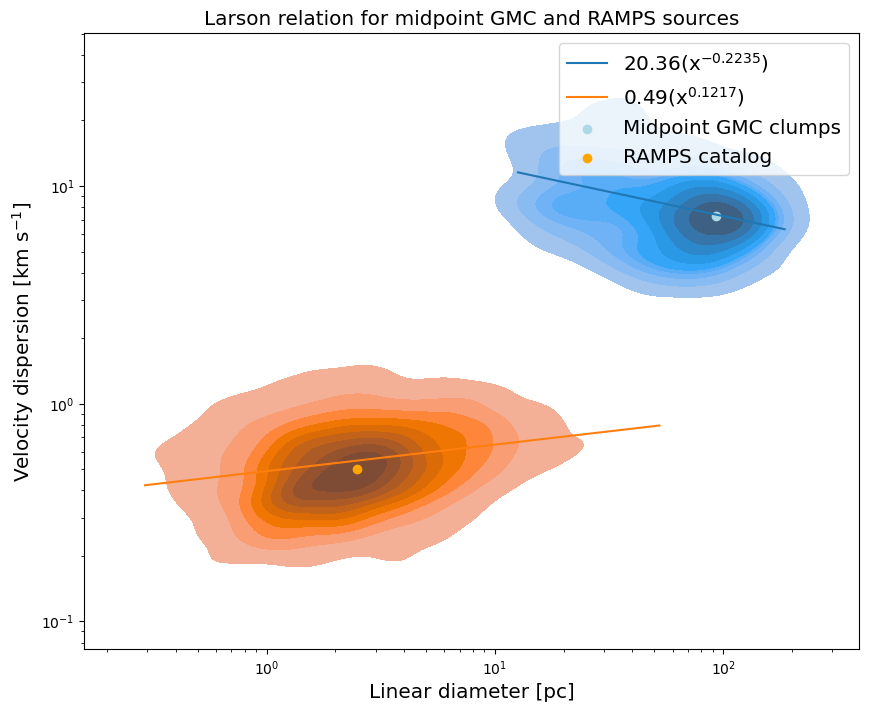

In [46]:
plt.figure(figsize= (10, 8))

plt.loglog()

# plt.scatter(pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'], label = 'Midpoint GMC clumps')
# plt.scatter(ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'], label = 'RAMPS catalog')

sns.kdeplot(x = pilot_table['Linear Size (pc)'], y = pilot_table['sigma (km/s)'], fill= True)
sns.kdeplot(x = ramps_table['Linear Size (pc)'], y = ramps_table['sigma (km/s)'], fill= True)

pilotopt, pilotcov = curve_fit(expFunc, pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'])
rampsopt, rampscov = curve_fit(expFunc, ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'])

plt.plot([min(pilot_table['Linear Size (pc)']), max(pilot_table['Linear Size (pc)'])], [expFunc(min(pilot_table['Linear Size (pc)']), *pilotopt), expFunc(max(pilot_table['Linear Size (pc)']), *pilotopt)], label= '%.2f(x$^{%.4f}$)' % tuple(pilotopt))
plt.plot([min(ramps_table['Linear Size (pc)']), max(ramps_table['Linear Size (pc)'])], [expFunc(min(ramps_table['Linear Size (pc)']), *rampsopt), expFunc(max(ramps_table['Linear Size (pc)']), *rampsopt)], label= '%.2f(x$^{%.4f}$)' % tuple(rampsopt))

plt.scatter(93, 7.3, color = 'lightblue', label = 'Midpoint GMC clumps')
plt.scatter(2.5, .5, color = 'orange', label = 'RAMPS catalog')

plt.title('Larson relation for midpoint GMC and RAMPS sources', fontsize= 'x-large')
plt.legend(fontsize = 'x-large')
plt.xlabel('Linear diameter [pc]', fontsize = 'x-large')
plt.ylabel('Velocity dispersion [km s$^{-1}$]', fontsize = 'x-large')

plt.show()